
Uniform model at 12 yards:
0.75424

Real-world model at 12 yards:
0.83421



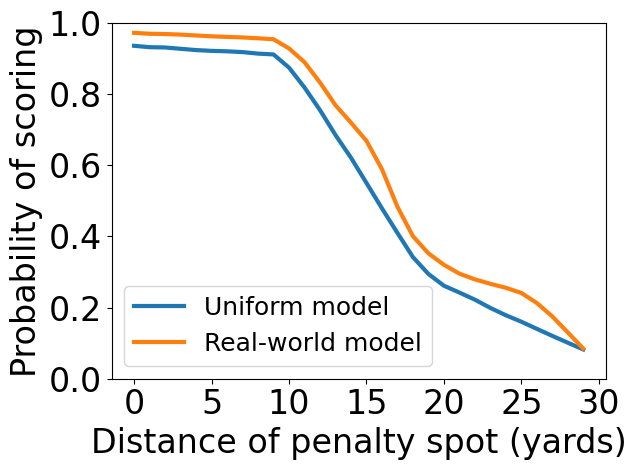

In [ ]:
import random
import math
import matplotlib.pyplot as plt

GOAL_WIDTH = 24
GOAL_HEIGHT = 8

KEEPER_X = GOAL_WIDTH / 2
KEEPER_Y = 3

BALL_SPEED = 110
REACTION_TIME = 0.25
DIVE_SPEED = 16
ARM_REACH = 2

def keeper_radius(distance):

    travel_time = distance / BALL_SPEED

    move_time = max(0, travel_time - REACTION_TIME)

    return ARM_REACH + DIVE_SPEED * move_time


def uniform_shot():

    x = random.uniform(0, GOAL_WIDTH)

    y = random.uniform(0, GOAL_HEIGHT)

    return x, y

# World Cup heatmap percentages

grid_probs = [

    [3.9, 3.1, 3.1, 1.6, 2.0, 3.1],

    [6.6, 5.1, 2.0, 0.8, 2.3, 9.0],

    [14.5,11.7,5.5,3.9,7.0,14.8]

]


# Convert grid into probability list

flat_probs = []

positions = []

cell_width = GOAL_WIDTH / 6

cell_height = GOAL_HEIGHT / 3


for row in range(3):

    for col in range(6):

        prob = grid_probs[row][col] / 100

        flat_probs.append(prob)

        x = (col + 0.5) * cell_width

        y = GOAL_HEIGHT - (row + 0.5) * cell_height

        positions.append((x,y))


# cumulative probabilities

cumulative = []
total = 0
for p in flat_probs:

    total += p

    cumulative.append(total)


def real_world_shot():

    r = random.random()

    for i in range(len(cumulative)):

        if r <= cumulative[i]:

            x, y = positions[i]

            # small spread within cell
            x += random.gauss(0,1)

            y += random.gauss(0,0.5)

            x = max(0, min(GOAL_WIDTH, x))

            y = max(0, min(GOAL_HEIGHT, y))

            return x, y

# Monte Carlo Simulation

def scoring_probability(distance_ft, shot_function, trials=100000):

    r = keeper_radius(distance_ft)

    saves = 0

    for _ in range(trials):

        x, y = shot_function()

        shot_left = x < GOAL_WIDTH / 2

        guess_prob = min(0.5, distance_ft / 80)

        if random.random() < guess_prob:

            keeper_x = KEEPER_X + (-r if shot_left else r)

        else:

            keeper_x = KEEPER_X

        keeper_y = KEEPER_Y

        d = math.sqrt((x - keeper_x)**2 + (y - keeper_y)**2)

        if d <= r:

            saves += 1

    return 1 - saves / trials

print()

print("Uniform model at 12 yards:")

print(scoring_probability(36, uniform_shot))

print()

print("Real-world model at 12 yards:")

print(scoring_probability(36, real_world_shot))

print()


distances = list(range(0,30))

uniform_probs = [

    scoring_probability(d*3, uniform_shot)

    for d in distances

]

real_probs = [

    scoring_probability(d*3, real_world_shot)

    for d in distances

]


plt.figure()

plt.plot(distances,
         uniform_probs,
         linewidth=3,
         label="Uniform model")

plt.plot(distances,
         real_probs,
         linewidth=3,
         label="Real-world model")

plt.xlabel("Distance of penalty spot (yards)", fontsize=24)

plt.ylabel("Probability of scoring", fontsize=24)

plt.ylim(0,1)

plt.legend(fontsize=18)

plt.xticks(fontsize=24)

plt.yticks(fontsize=24)

plt.tight_layout()

plt.savefig("real_world_model_comparison.pdf")

plt.show()